In [6]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.utils.dataset_ops import (
    summary,
    system_selection,
    select_systems,
    left,
    upd_n_mol,
)
from src.utils.small_molecules import (
    collect_small_molecules,
    remove_selected_small,
    drop_rows_with_forbidden_small,
)
from src.utils.solvents import load_solvent_set, remove_solvents
from src.utils.composition import metal_summary
from src.utils.visualization import visual

### Загрузка исходного датасета

В датасете представлены комбинации молекул из Cambridge Structural Database, образующие со-кристаллы.

1 строка = 1 комбинация.

Комбинации были получены из CIF файлов.

Число молекул в комбинациях не фиксировано.

- source_file - имя CIF файла
- formula_i - формула молекулы
- xyz_i - координаты атомов в xyz формате
- n_molecules - количество молекул в комбинации (строке)
- has_metal - флаг наличия металла в комбинации (строке)

In [7]:
raw = pd.read_pickle(ROOT / 'data' / 'raw' / 'csd_raw.pkl')

In [8]:
raw.head(2)

,source_file,formula_1,formula_2,formula_3,formula_4,formula_5,formula_6,formula_7,formula_8,formula_9,...,xyz_3,xyz_4,xyz_5,xyz_6,xyz_7,xyz_8,xyz_9,xyz_10,n_molecules,has_metal
0,ABABIQ,C21N3O4F,Cl2,O2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,1\nO1\nO 0.000000 0.000000 0.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,False
1,ABADUF,CuC3(SN2)3,CO2,O2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,1\nO1\nO 0.000000 0.000000 0.000000,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,3,True


### Удаление молекул растворителей из комбинаций

- xyz конвертируются в mol через OpenBabel
- для каждой молекулы генерируются каноничные smiles rdkit
- smiles каждой молекулы сравнивается со smiles растворителя
- если smiles одинаковые, это растворитель и он удаляется
- если не удалось сгенерировать smiles для молекулы - значит она сложная, это точно не растворитель, пропускается


In [9]:
solvent_set = load_solvent_set(ROOT / 'resources' / 'solvents_canonical.txt')
print(f'В списке {len(solvent_set)} уникальных растворителей')

В списке 600 уникальных растворителей


In [ ]:
df_no_solv, removed_solvents = remove_solvents(raw, solvent_set)

In [11]:
formula_cols = [c for c in raw.columns if c.startswith('formula_')]

before = raw[formula_cols].notna().sum().sum()
after  = df_no_solv[formula_cols].notna().sum().sum()

print(f'Удалено {int(before - after)} молекул растворителей')

Удалено 92041 молекул растворителей


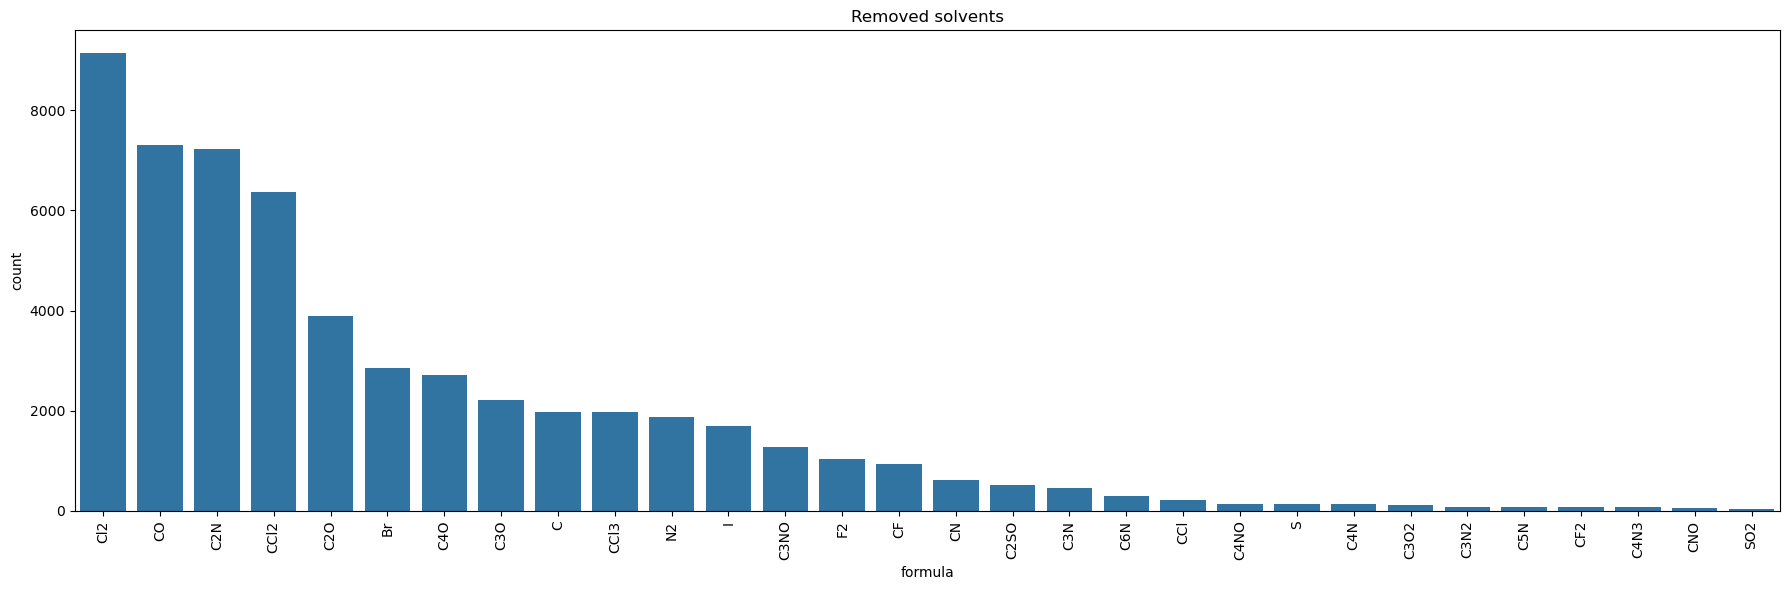

In [12]:
rs = (
    removed_solvents
    .query('formula != "O2"')
    .sort_values('count', ascending=False)
)

top_n = 30
plot_df = rs.head(top_n)

plt.figure(figsize=(18, 6))
sns.barplot(data=plot_df, x='formula', y='count')

plt.xticks(rotation=90)
plt.title('Removed solvents')
plt.tight_layout()
plt.show()

### Проверка мелких молекул (менее 3 неводородных атомов)

In [13]:
all_small = collect_small_molecules(df_no_solv, max_atoms=2)

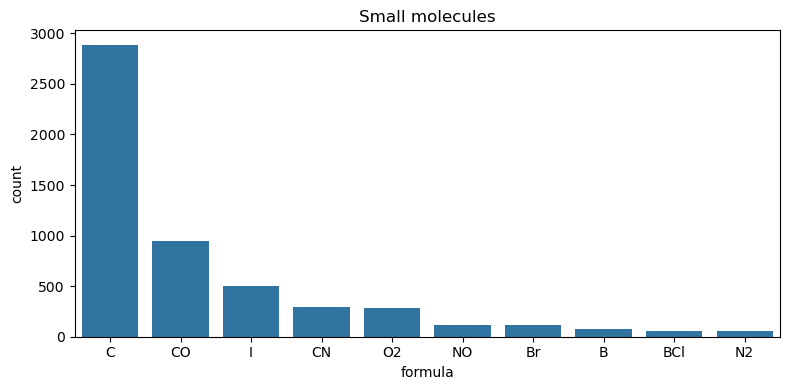

In [14]:
top10 = all_small.head(10)

plt.figure(figsize=(8, 4))
sns.barplot(data=top10, x='formula', y='count')
plt.title('Small molecules')
plt.tight_layout()
plt.show()

Удаление разрешенных малых молекул из каждой комбинации

In [15]:
allowed_small = {'O2'}

df_no_small_1, removed_small_summary = remove_selected_small(
    df_no_solv,
    small=allowed_small,
)

In [16]:
n_removed_molecules = removed_small_summary['count'].sum()

rows_with_removal = removed_small_summary['n_files'].sum()
n_total_rows = len(df_no_solv)
share_rows = rows_with_removal / n_total_rows

print(
    f'Удалено {n_removed_molecules:,} малых молекул\n'
    f'Затронуто {rows_with_removal:,} строк '
    f'({share_rows:.2%})'
)

Удалено 287 малых молекул
Затронуто 287 строк (0.40%)


Удаление комбинаций (строк) с прочими малыми молекулами (их присутствие означает ошибку парсинга файла)

In [17]:
df_no_small_2, removed_rows_df = drop_rows_with_forbidden_small(
    df_no_small_1,
    all_small=set(all_small['formula']),
    allowed_small=allowed_small,
)

In [18]:
n_removed_rows = removed_rows_df['n_rows_removed'].sum()
n_initial_rows = len(df_no_solv)

share_removed_rows = n_removed_rows / n_initial_rows

print(f'Удалено {n_removed_rows} некорректных строк ({share_removed_rows:.2%})')


Удалено 5404 некорректных строк (7.47%)


При визуальной проверке 500 комбинаций было замечено, что фрагменты "CF3", "SO3", "CO2" тоже означают ошибку парсинга. Такие примеры удаляются.

In [19]:
cols = ['formula_1', 'formula_2', 'formula_3']
pattern = r'^(CF3|SO3|CO2)$'

mask = (
    df_no_small_2[cols]
    .fillna('')
    .apply(lambda row: row.str.contains(pattern, regex=True))
    .any(axis=1)
)

df_no_small_3 = df_no_small_2.loc[~mask].copy()

/var/folders/5z/kgtkx42x6m903p6t4mwrqwk40000gn/T/ipykernel_14325/2207583211.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .apply(lambda row: row.str.contains(pattern, regex=True))


In [20]:
n_before = len(df_no_small_2)
n_after = len(df_no_small_3)

n_removed = n_before - n_after
pct_removed = n_removed / n_before 

print(f'Удалено {n_removed} некорректных строк ({pct_removed:.2%})')


Удалено 4027 некорректных строк (6.01%)


### Оценка содержания металлов

In [21]:
df_3_single_df = select_systems(df_no_small_3, n_components=3, single_df=True)
ms = metal_summary(df_3_single_df)

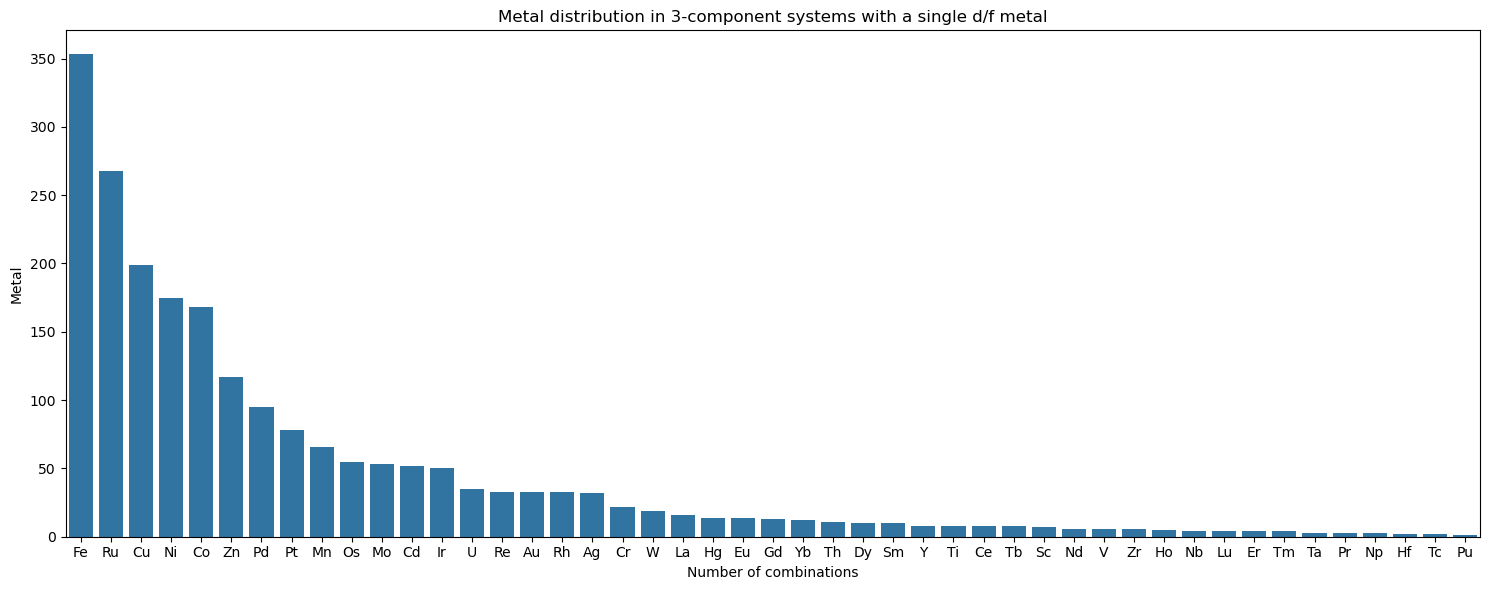

In [22]:
plt.figure(figsize=(15, 6))
sns.barplot(data=ms, x='metal', y='n_combinations')

plt.title('Metal distribution in 3-component systems with a single d/f metal')
plt.xlabel('Number of combinations')
plt.ylabel('Metal')
plt.tight_layout()
plt.show()

### Оценка очищенного датасета

### Изменение количества комбинаций с заданными характеристиками 

с целью выбрать, как фильтровать и на каком шаге остановиться
1. raw - исходный датасет
2. no_solv - удалены растворители
3. no_small_1 - удалены мелкие молекулы
4. no_small_2 - удалены некорректные комбинации с подозрительными малыми молекулами
5. no_small_3 - удалены некорректные комбинации, содержащие "CF3", "SO3", "CO2"

In [23]:
datasets = {
    'raw': raw,
    'no_solv': df_no_solv,
    'no_small_1': df_no_small_1,
    'no_small_2': df_no_small_2,
    'no_small_3' : df_no_small_3,
}

summaries = []
for name, d in datasets.items():
    s = summary(d).copy()
    s['stage'] = name
    summaries.append(s)

summary_all = pd.concat(summaries, ignore_index=True)

In [24]:
metrics_main = [
    'total',
    'without_metal',
    'single_df',
    'single_df_sulfonic_amine',
    'amine_sulfonic_any',
]

plot_df_heat = (
    summary_all
    .query('n_components == 3')
    [['stage'] + metrics_main]
    .set_index('stage')
    .T
)

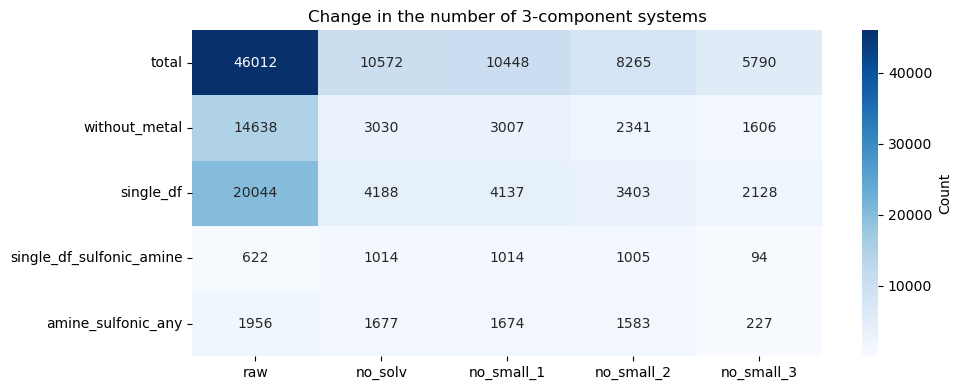

In [25]:
plt.figure(figsize=(10, 4))
sns.heatmap(
    plot_df_heat,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    cbar_kws={'label': 'Count'}
)

plt.title('Change in the number of 3-component systems')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

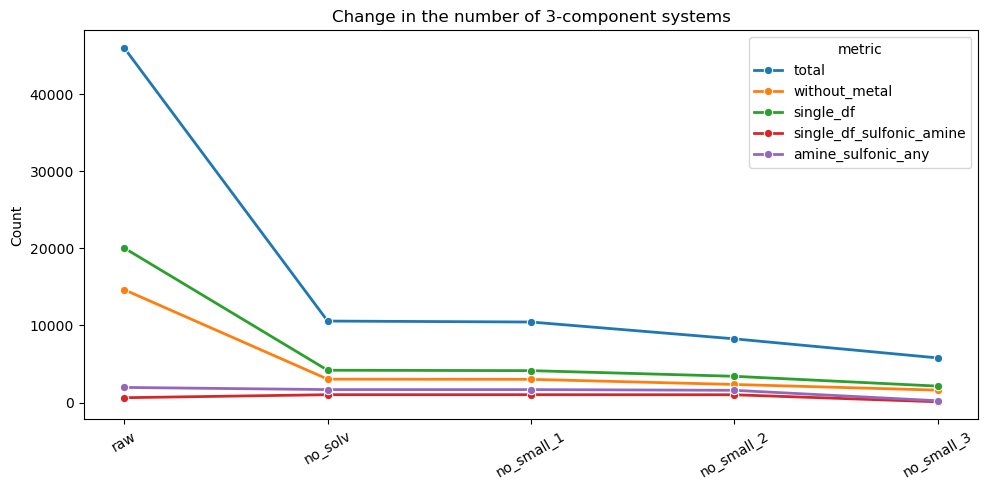

In [26]:
plot_df = (
    summary_all
    .query('n_components == 3')
    [['stage'] + metrics_main]
    .melt(id_vars='stage', var_name='metric', value_name='count')
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=plot_df,
    x='stage',
    y='count',
    hue='metric',
    marker='o',
    linewidth=2,
)

plt.title('Change in the number of 3-component systems')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Большинство комбинаций 'теряется' на шаге удаления растворителя. Это происходит из-за того, что растворитель не считается самостоятельным компонентом. Дальнейшие шаги удаляют не так много комбинаций, но обеспечивают чистоту данных. Таким образом, можем взять датасет с комбинациями, содержащими 3 компонента, после всех шагов очистки. 

Количества всех комбинаций после полной очистки

In [27]:
summary(df_no_small_3)

,n_components,total,without_metal,with_metal,with_df,single_metal,single_df,single_metal_sulfonic_amine,single_df_sulfonic_amine,amine_sulfonic_any
1,1,18115,8977,9138,8280,7129,6393,129,117,409
2,2,36456,9257,27199,25139,18144,16509,584,549,1777
3,3,5790,1606,4184,3841,2321,2128,111,94,227
4,4,633,248,385,356,154,142,3,2,12
5,5,126,58,68,64,26,25,4,4,8
6,6,17,8,9,8,4,3,1,1,1
7,7,3,1,2,2,1,1,0,0,0


### Сохранение подготовленного датасета

In [28]:
df_triple = select_systems(df_no_small_3, n_components=3)
df_triple = df_triple.reset_index(drop=True)

df_triple = df_triple[
        ['source_file',
        'formula_1', 'formula_2', 'formula_3',
        'xyz_1', 'xyz_2', 'xyz_3',
        'n_molecules',
        'has_metal']
    ]

df_triple.shape[0]

5790

In [29]:
df_triple.to_pickle(ROOT / 'data' / 'raw' / 'triple_pos_raw.pkl')


In [30]:
df_triple.head(3)

,source_file,formula_1,formula_2,formula_3,xyz_1,xyz_2,xyz_3,n_molecules,has_metal
0,ABAXUY,OsC8N3,PC9,PF6,12\nOs1 C8 N3\nN -1.726751 -0.068357 0.201085\...,10\nP1 C9\nP 0.133927 -0.645601 0.276390\nC 0....,7\nP1 F6\nF 0.701604 1.059999 0.976954\nF -1.1...,3,True
1,ABEZUD,RuC18N6Cl,PC18,BF4,26\nRu1 C18 N6 Cl1\nCl -2.885418 2.877852 -1.5...,19\nP1 C18\nP -0.683952 0.942133 -0.178916\nC ...,5\nB1 F4\nB 0.009008 0.030424 -0.016752\nF -0....,3,True
2,ABIBAP,RuC18N6Cl,AsC18,BF4,26\nRu1 C18 N6 Cl1\nCl -2.868267 -2.893902 -1....,19\nAs1 C18\nAs -0.605246 -0.841529 -0.152435\...,5\nB1 F4\nB 0.002937 -0.041245 0.018796\nF 1.1...,3,True
